In [1]:
# import tensorflow as tf
# tf.config.run_functions_eagerly(True)

In [2]:
import cv2
import keras
import os
import mediapipe as mp
import numpy as np
import tensorflow as tf
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.callbacks import TensorBoard
import matplotlib.pyplot as plt

In [3]:
EPOCHS = 80 # 500
BATCH_SIZE = 16
LEARNING_RATE = 0.0001
DATA_PATH = os.path.join('mp_data')
EMOTIONS = np.array(['happy', 'sad', 'angry'])
NO_SEQ = 30
SEQ_LENGTH = 30
# MODEL_PATH = './backend/model.h5'
MODEL_PATH = './model_mlp.h5'

In [4]:
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils
mp_face_mesh = mp.solutions.face_mesh

In [5]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.setflags(write=False)
    results = model.process(image)
    image.setflags(write=True)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, results

In [6]:
def draw_styled_landmarks(image, results):
    # Draw face connections
    mp_drawing.draw_landmarks(
      image, results.face_landmarks, mp_holistic.FACEMESH_CONTOURS,
      mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
      mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [7]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])


In [8]:
for emotion in EMOTIONS:
    for sequence in range(NO_SEQ):
        try:
            os.makedirs(os.path.join(DATA_PATH, emotion, str(sequence)))
        # if created -> pass 
        except: 
            pass

In [9]:
# #Main function
# cap = cv2.VideoCapture(0)
# # Set mediapipe model 
# with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:

#     for emotion in EMOTIONS:
#         for sequence in range(NO_SEQ):
#             for frame_num in range(SEQ_LENGTH):

#                 # Read feed
#                 ret, frame = cap.read()

#                 # Make detections
#                 image, results = mediapipe_detection(frame, holistic)
#                 print(results)
                
#                 # Draw landmarks
#                 draw_styled_landmarks(image, results)

#                 # Apply wait logic
#                 if frame_num == 0:
#                     cv2.putText(image, 'STARTING COLLECTION', (120,200), 
#                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 4, cv2.LINE_AA)
#                     cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(emotion, sequence), (15,12), 
#                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1, cv2.LINE_AA)
#                     # Show to screen
#                     cv2.imshow('Holistic Model', image)
#                     cv2.waitKey(2000)
#                 else: 
#                     cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(emotion, sequence), (15,12), 
#                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1, cv2.LINE_AA)
#                     # Show to screen
#                     cv2.imshow('Holistic Model', image)
                
#                 # Export keypoints
#                 keypoints = extract_keypoints(results)
#                 npy_path = os.path.join(DATA_PATH, emotion, str(sequence), str(frame_num))
#                 np.save(npy_path, keypoints)

#                 # Break gracefully
#                 if cv2.waitKey(10) & 0xFF == ord('q'):
#                     break
# cap.release()
# cv2.destroyAllWindows()

In [10]:
# extract_keypoints(results).shape

### Collection Done -> Preprocess Data for training

In [11]:
label_map = {label:num for num, label in enumerate(EMOTIONS)}
label_map

{np.str_('happy'): 0, np.str_('sad'): 1, np.str_('angry'): 2}

In [12]:
sequences, labels = [], []
for emotion in EMOTIONS:
    for sequence in range(NO_SEQ):
        window =[]
        for frame_num in range(SEQ_LENGTH):
            res = np.load(os.path.join(DATA_PATH, emotion, str(sequence), "{}.npy".format(frame_num)))
            window.append(res) # grab frame, add to window(video)

        sequences.append(window)
        labels.append(label_map[emotion])

In [13]:
X = np.array(sequences)
y = to_categorical(labels).astype(int)
X.shape, y.shape

((90, 30, 1662), (90, 3))

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [15]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((72, 30, 1662), (72, 3), (18, 30, 1662), (18, 3))

In [16]:
# FOR MLP
X_train_flat = X_train[:,0,:]
X_test_flat = X_test[:,0,:]

In [17]:
def add_noise(keypoints, std=0.01):
    noise = np.random.normal(0, std, keypoints.shape)
    return keypoints + noise


In [18]:
def scale_xy(keypoints, scale_range=(0.95, 1.05)):
    kp = keypoints.copy()
    scale = np.random.uniform(*scale_range)
    kp[::3] *= scale      # x
    kp[1::3] *= scale    # y
    return kp


In [19]:
def dropout_keypoints(keypoints, drop_prob=0.02):
    kp = keypoints.copy()
    mask = np.random.rand(len(kp)) > drop_prob
    kp *= mask
    return kp


In [20]:
X_aug = []
y_aug = []

for x, y in zip(X_train_flat, y_train):
    x_aug = add_noise(x, std=0.01)
    x_aug = scale_xy(x_aug)
    x_aug = dropout_keypoints(x_aug, drop_prob=0.02)

    X_aug.append(x_aug)
    y_aug.append(y)

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

# Combine original + augmented
X_train_aug = np.vstack([X_train_flat, X_aug])
y_train_aug = np.vstack([y_train, y_aug])

print(X_train_aug.shape, y_train_aug.shape)


(144, 1662) (144, 3)


In [21]:
X_train_flat.shape, X_test_flat.shape


((72, 1662), (18, 1662))

In [22]:
X_train_aug.shape, y_train_aug.shape

((144, 1662), (144, 3))

### Preprocessing Done -> Build & Train Model

In [23]:
log_dir = os.path.join('Logs')
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)

In [24]:
OPTIMIZER = Adam(learning_rate=LEARNING_RATE)

In [25]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1662,)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(3, activation="softmax")
])


In [26]:
# early_stop = tf.keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     patience=12,
#     restore_best_weights=True
# )

In [27]:
model.compile(optimizer=OPTIMIZER, loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [28]:
model.fit(
    X_train_aug,
    y_train_aug,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_flat, y_test),
    callbacks=[tensorboard_callback]
)

Epoch 1/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - categorical_accuracy: 0.3472 - loss: 1.1350 - val_categorical_accuracy: 0.4444 - val_loss: 1.0445
Epoch 2/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - categorical_accuracy: 0.3264 - loss: 1.1831 - val_categorical_accuracy: 0.4444 - val_loss: 1.0453
Epoch 3/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - categorical_accuracy: 0.3403 - loss: 1.1367 - val_categorical_accuracy: 0.4444 - val_loss: 1.0332
Epoch 4/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - categorical_accuracy: 0.3056 - loss: 1.1559 - val_categorical_accuracy: 0.6667 - val_loss: 1.0441
Epoch 5/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - categorical_accuracy: 0.3819 - loss: 1.0973 - val_categorical_accuracy: 0.3889 - val_loss: 1.0481
Epoch 6/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - categorical_accuracy: 0.3750 - loss: 1.1429 - val_categorical_accuracy: 0.6667 - val_loss: 1.0390
Epoch 7/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - categorical_accuracy: 0.4583 - loss: 1.0339 - val_categ

In [29]:
# model.fit(
#     X_train_flat,
#     y_train,
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     validation_data=(X_test_flat, y_test),
#     callbacks=[tensorboard_callback, early_stop]
# )

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         425,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,401,227 (5.35 MB)

 Trainable params: 467,075 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 934,152 (3.56 MB)

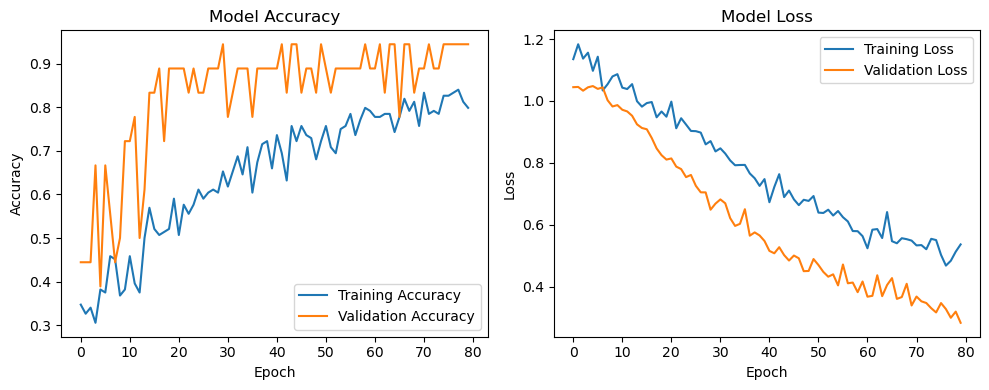

In [31]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(model.history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(model.history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(model.history.history['loss'], label='Training Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
res = model.predict(X_test_flat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


In [33]:
EMOTIONS[np.argmax(res[0])]

np.str_('happy')

In [34]:
EMOTIONS[np.argmax(y[0])]

np.str_('happy')

In [35]:
model.save(MODEL_PATH)

In [36]:
model.load_weights(MODEL_PATH)

### Training Done -> Test in real time

In [37]:
# # RENDER PROBABILITY
# colors = [(245,117,16), (117,245,16), (16,117,245)]
# def prob_viz(res, actions, input_frame, colors):
#     output_frame = input_frame.copy()
#     for num, prob in enumerate(res):
#         cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
#         cv2.putText(output_frame, actions[num], (0,85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
#     return output_frame

In [38]:
# sequence = []
# emotions = []
# predictions = []
# threshold = 0.5

# cap = cv2.VideoCapture(0)
# # Set mediapipe model
# with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
#     while cap.isOpened():

#         # Read feed
#         ret, frame = cap.read()

#         # Make detections
#         image, results = mediapipe_detection(frame, holistic)
#         print(results)

#         # Draw landmarks
#         draw_styled_landmarks(image, results)

#         # 2. Prediction logic
#         keypoints = extract_keypoints(results)
#         sequence.append(keypoints)
#         sequence = sequence[-SEQ_LENGTH:]

#         if len(sequence) == SEQ_LENGTH:
#             res = model.predict(np.expand_dims(sequence, axis=0))[0]
#             print(EMOTIONS[np.argmax(res)])
#             predictions.append(np.argmax(res))


#         #3. Viz logic
#             if np.unique(predictions[-10:])[0]==np.argmax(res): 
#                 if res[np.argmax(res)] > threshold: 
#                     if len(emotions) > 0:
#                         if EMOTIONS[np.argmax(res)] != emotions[-1]:
#                             emotions.append(EMOTIONS[np.argmax(res)])
#                     else:
#                         emotions.append(EMOTIONS[np.argmax(res)])
            
#             if len(emotions) > 3:
#                 emotions = emotions[-3:]
#             # Viz probabilities
#             image = prob_viz(res, EMOTIONS, image, colors)

#         cv2.rectangle(image, (0,0), (250, 60), (245, 117, 16), -1)
#         cv2.putText(image, 'EMOTION: {}'.format(emotions[-1] if len(emotions) > 0 else ''), (10,40), 
#                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

#         # Show to screen
#         cv2.imshow('Holistic Model', image)

#         # Break gracefully
#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break
#     cap.release()
#     cv2.destroyAllWindows()